<a href="https://colab.research.google.com/github/Wahdaapf/PCVK_Ganjil_2026/blob/main/Week5_24.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# E1

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

<BarContainer object of 256 artists>

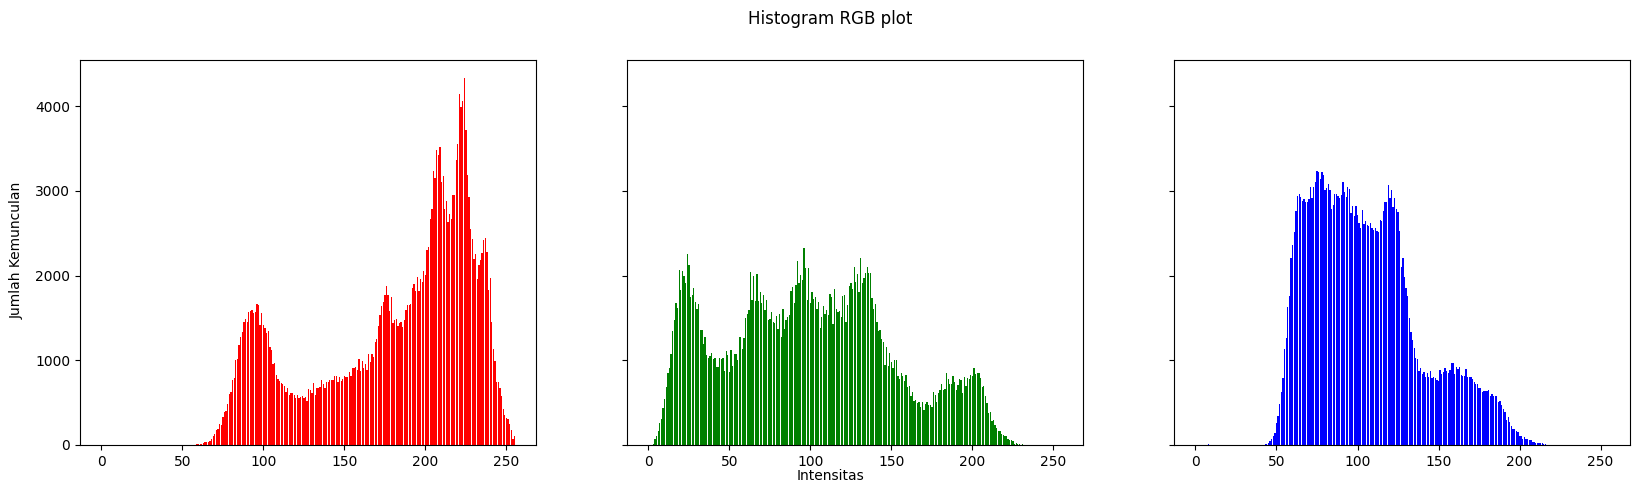

In [3]:
# membuat histogram image (manual)
img = cv.imread('/content/drive/MyDrive/Google Collab/Lenna.png')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
green = [0]*256
blue = [0]*256

for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20,5), sharex=True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

# E1.1

In [4]:
# E1.1 - Histogram Manual

def histogram_manual(img, L=256):
    h = np.zeros(L, dtype=np.int64)

    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1

    return h

In [5]:
# E1.1 - Lena/Lenna.png

lena = cv.imread(
    '/content/drive/MyDrive/Google Collab/Lenna.png',
    cv.IMREAD_GRAYSCALE
)

# Histogram manual
hist_manual = histogram_manual(lena)

# Histogram menggunakan NumPy
hist_numpy, bins = np.histogram(
    lena,
    bins=256,
    range=(0, 256)
)

# Histogram menggunakan OpenCV
hist_cv = cv.calcHist(
    [lena],
    [0],
    None,
    [256],
    [0, 256]
)

hist_cv = hist_cv.flatten().astype(np.int64)

# Menghitung selisih maksimum
selisih_manual_numpy = np.max(
    np.abs(hist_manual - hist_numpy)
)

selisih_manual_cv = np.max(
    np.abs(hist_manual - hist_cv)
)

selisih_numpy_cv = np.max(
    np.abs(hist_numpy - hist_cv)
)

print("=== E1.1 - LENNA.PNG ===")
print("Selisih maksimum Manual vs NumPy :", selisih_manual_numpy)
print("Selisih maksimum Manual vs cv.calcHist :", selisih_manual_cv)
print("Selisih maksimum NumPy vs cv.calcHist :", selisih_numpy_cv)

=== E1.1 - LENNA.PNG ===
Selisih maksimum Manual vs NumPy : 0
Selisih maksimum Manual vs cv.calcHist : 0
Selisih maksimum NumPy vs cv.calcHist : 0


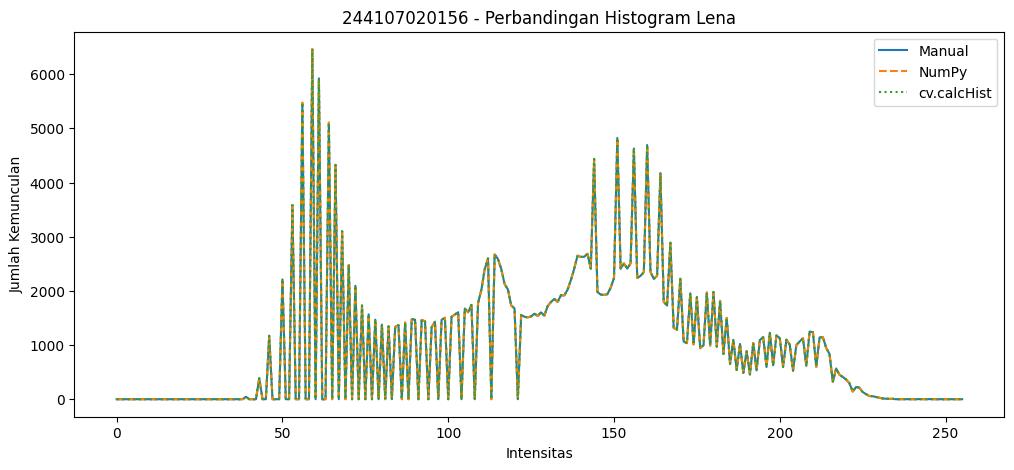

In [6]:
plt.figure(figsize=(12, 5))

plt.plot(hist_manual, label='Manual')
plt.plot(hist_numpy, '--', label='NumPy')
plt.plot(hist_cv, ':', label='cv.calcHist')

plt.title('244107020156' + ' - Perbandingan Histogram Lena')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Kemunculan')
plt.legend()
plt.show()

In [7]:
# E1.1 - KTM1b.jpg

ktm1b = cv.imread('/content/drive/MyDrive/Google Collab/ktm.jpg', cv.IMREAD_GRAYSCALE)

# Histogram manual
hist_manual = histogram_manual(ktm1b)

# Histogram NumPy
hist_numpy, bins = np.histogram(ktm1b, bins=256, range=(0, 256))

# Histogram OpenCV
hist_cv = cv.calcHist([ktm1b], [0], None, [256], [0, 256])
hist_cv = hist_cv.flatten().astype(np.int64)

# Selisih maksimum
selisih_manual_numpy = np.max(np.abs(hist_manual - hist_numpy))
selisih_manual_cv = np.max(np.abs(hist_manual - hist_cv))
selisih_numpy_cv = np.max(np.abs(hist_numpy - hist_cv))

print("=== E1.1 - KTM1b.JPG ===")
print("Selisih maksimum Manual vs NumPy :", selisih_manual_numpy)
print("Selisih maksimum Manual vs cv.calcHist :", selisih_manual_cv)
print("Selisih maksimum NumPy vs cv.calcHist :", selisih_numpy_cv)

=== E1.1 - KTM1b.JPG ===
Selisih maksimum Manual vs NumPy : 0
Selisih maksimum Manual vs cv.calcHist : 0
Selisih maksimum NumPy vs cv.calcHist : 0


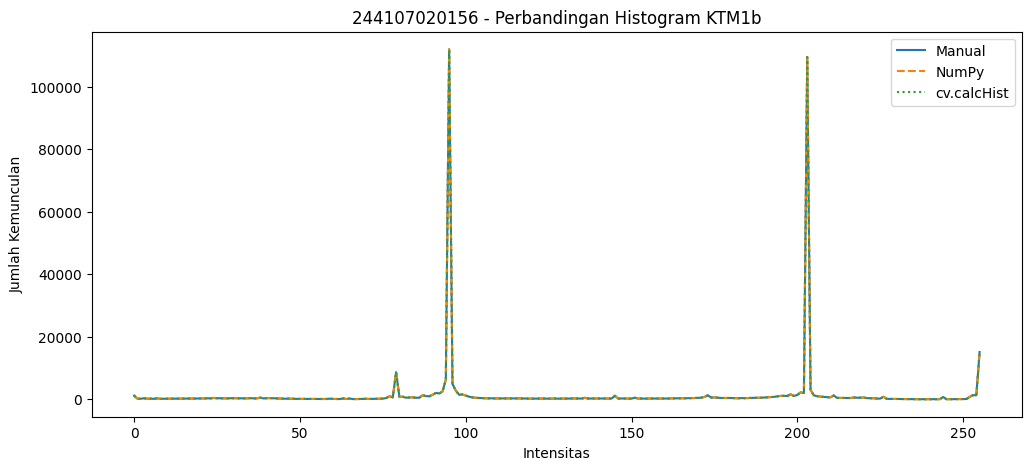

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(hist_manual, label='Manual')
plt.plot(hist_numpy, '--', label='NumPy')
plt.plot(hist_cv, ':', label='cv.calcHist')

plt.title('244107020156' + ' - Perbandingan Histogram KTM1b')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Kemunculan')
plt.legend()
plt.show()

# E1.2

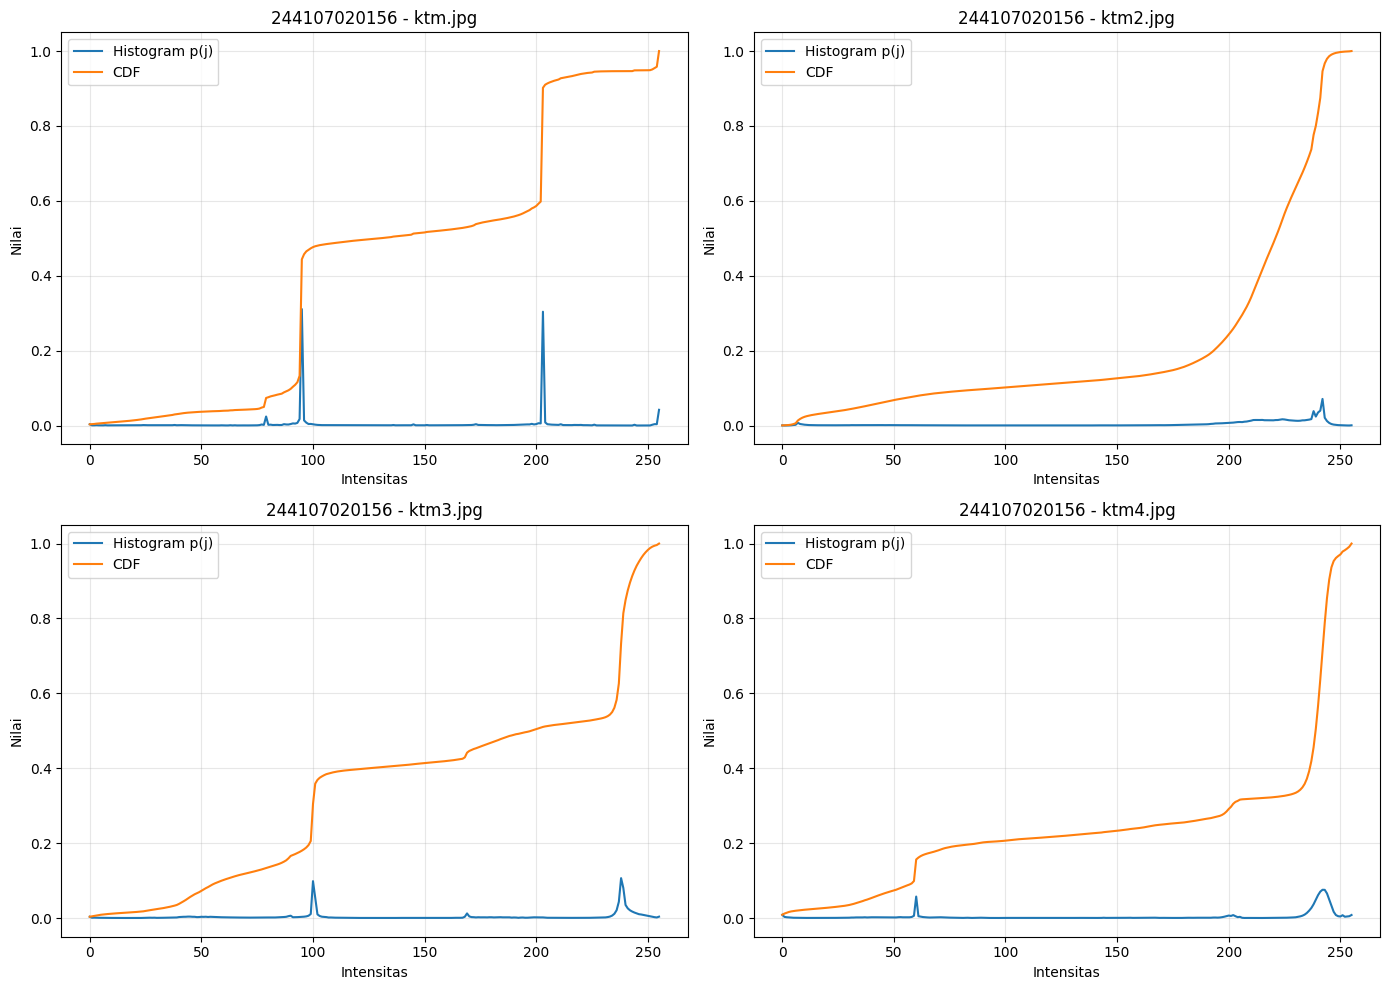

In [9]:
# E1.2 - Histogram Normalisasi dan CDF
# KTM1a sampai KTM1d

nama_file = ['ktm.jpg', 'ktm2.jpg', 'ktm3.jpg', 'ktm4.jpg']

plt.figure(figsize=(14, 10))

for i, nama in enumerate(nama_file, 1):

    # Membaca citra grayscale
    img = cv.imread('/content/drive/MyDrive/Google Collab/' + nama, cv.IMREAD_GRAYSCALE)

    # Histogram
    h = histogram_manual(img)

    # Histogram ternormalisasi p(j)
    p = h / img.size

    # CDF
    cdf = np.cumsum(p)

    # Subplot 2x2
    plt.subplot(2, 2, i)

    plt.plot(p, label='Histogram p(j)')
    plt.plot(cdf, label='CDF')

    plt.title('244107020156' + ' - ' + nama)
    plt.xlabel('Intensitas')
    plt.ylabel('Nilai')
    plt.legend()
    plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
print("=== Rata-rata Intensitas ===")

for nama in nama_file:
    img = cv.imread('/content/drive/MyDrive/Google Collab/' + nama, cv.IMREAD_GRAYSCALE)
    rata = img.mean()

    print(f"{nama}: {rata:.2f}")

=== Rata-rata Intensitas ===
ktm.jpg: 146.58
ktm2.jpg: 201.11
ktm3.jpg: 168.88
ktm4.jpg: 194.52


# E1.3

In [11]:
import sys
import platform
import hashlib
import datetime
import zoneinfo

NAMA = 'Wahda Adella Putri Febriana'
NIM = '244107020156'

N = int(NIM[-3:])

PARAM = {
    'bins': 2 ** ((N % 4) + 3),
    'clip': round(1.0 + (N % 5) * 0.5, 1),
    'tile': (N % 4) + 2,
    'L': 2 ** ((N % 3) + 1),
}

waktu = datetime.datetime.now(
    zoneinfo.ZoneInfo('Asia/Jakarta')
)

print('NAMA :', NAMA)
print('NIM :', NIM)
print('N =', N)
print('PARAM =', PARAM)

NAMA : Wahda Adella Putri Febriana
NIM : 244107020156
N = 156
PARAM = {'bins': 8, 'clip': 1.5, 'tile': 2, 'L': 2}


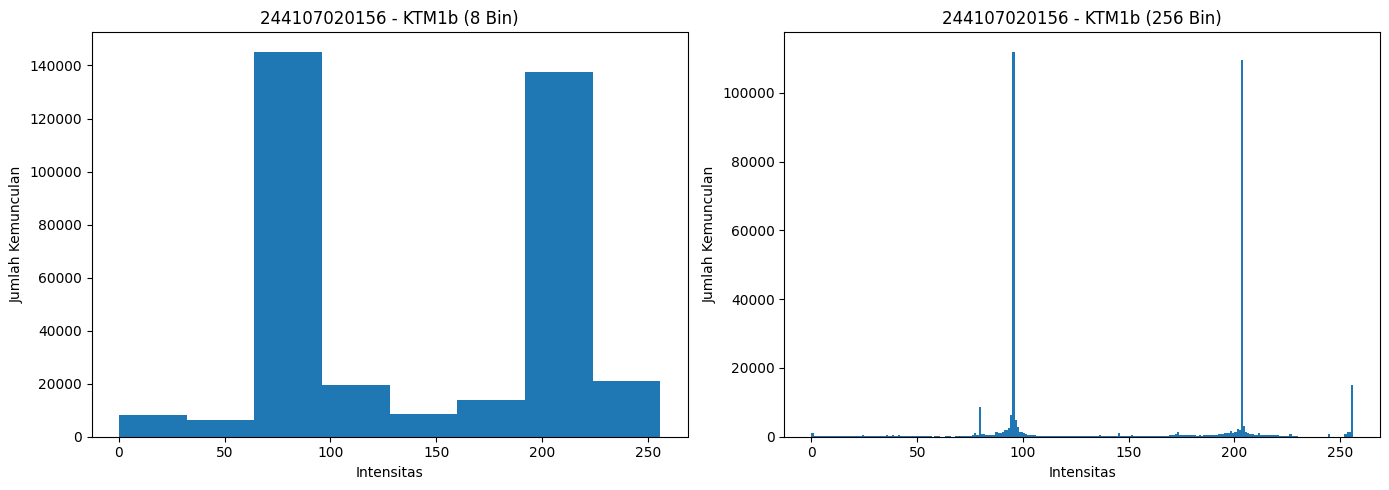

Jumlah bin berdasarkan NIM : 8
Jumlah bin pembanding      : 256


In [12]:
# E1.3 - Perbandingan jumlah bin

img = cv.imread('/content/drive/MyDrive/Google Collab/ktm.jpg', cv.IMREAD_GRAYSCALE)

jumlah_bin = PARAM['bins']

plt.figure(figsize=(14, 5))

# Histogram dengan PARAM['bins']
plt.subplot(1, 2, 1)

plt.hist(
    img.ravel(),
    bins=jumlah_bin,
    range=(0, 256)
)

plt.title(NIM + f' - KTM1b ({jumlah_bin} Bin)')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Kemunculan')

# Histogram dengan 256 bin
plt.subplot(1, 2, 2)

plt.hist(
    img.ravel(),
    bins=256,
    range=(0, 256)
)

plt.title(NIM + ' - KTM1b (256 Bin)')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

print("Jumlah bin berdasarkan NIM :", PARAM['bins'])
print("Jumlah bin pembanding      : 256")

# E2

# No 1

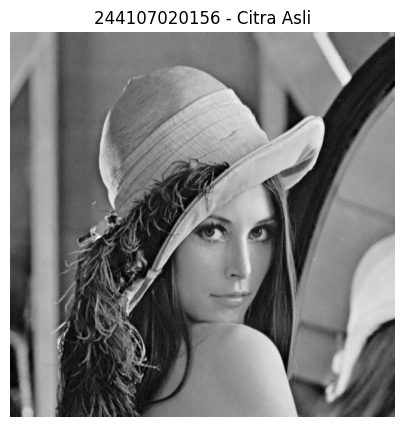

In [13]:
# E-2.1 - Membaca citra

img = cv.imread(
    '/content/drive/MyDrive/Google Collab/Lenna.png',
    cv.IMREAD_GRAYSCALE
)

plt.figure(figsize=(6, 5))
plt.imshow(img, cmap='gray')
plt.title(NIM + ' - Citra Asli')
plt.axis('off')
plt.show()

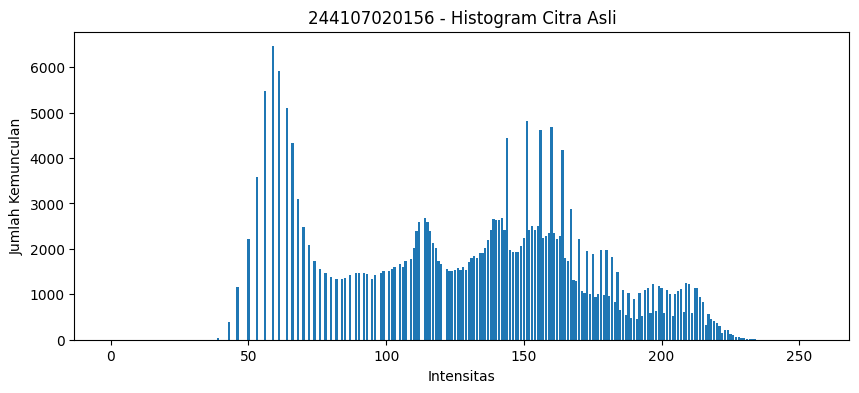

In [14]:
# Histogram citra asli

hist = histogram_manual(img)

plt.figure(figsize=(10, 4))
plt.bar(np.arange(256), hist)

plt.title(NIM + ' - Histogram Citra Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Kemunculan')

plt.show()

In [15]:
# Histogram Equalization Manual

# Hitung histogram
hist = histogram_manual(img)

# Hitung probabilitas setiap intensitas
prob = hist / img.size

# Hitung CDF
cdf = np.cumsum(prob)

# Transformasi histogram equalization
L = 256
transform = np.round((L - 1) * cdf).astype(np.uint8)

# Terapkan transformasi ke citra
img_equalized = transform[img]

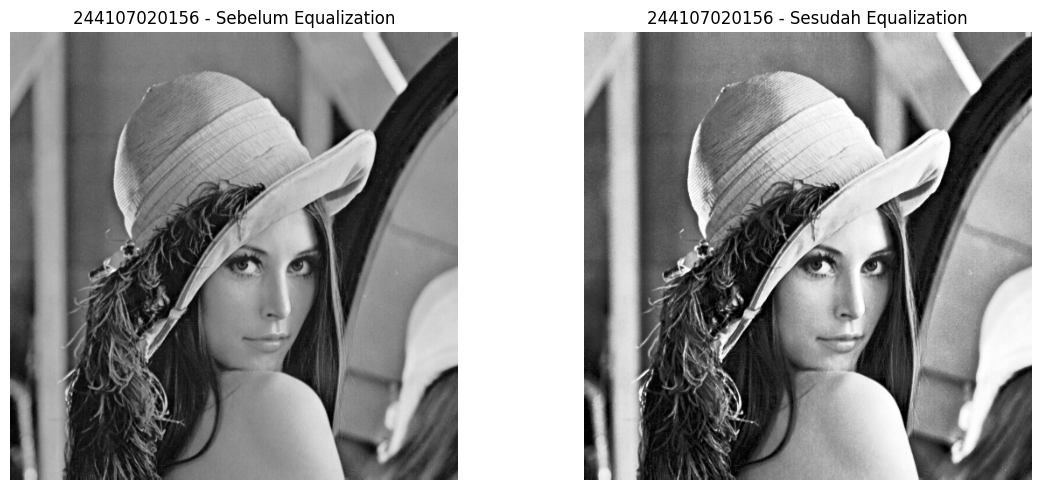

In [16]:
# Menampilkan citra sebelum dan sesudah equalization

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title(NIM + ' - Sebelum Equalization')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_equalized, cmap='gray')
plt.title(NIM + ' - Sesudah Equalization')
plt.axis('off')

plt.tight_layout()
plt.show()

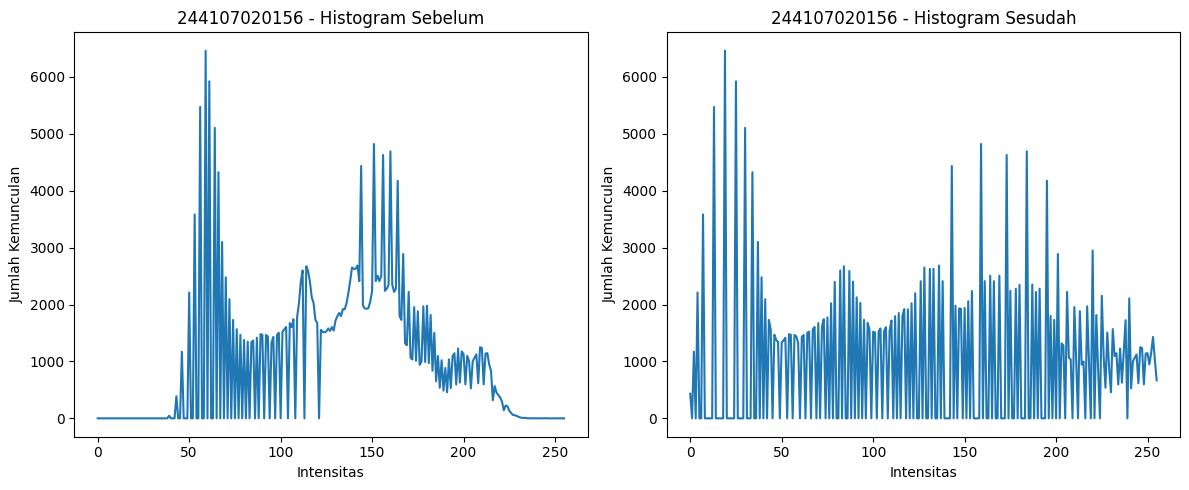

In [17]:
# Histogram sebelum dan sesudah

hist_before = histogram_manual(img)
hist_after = histogram_manual(img_equalized)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(hist_before)
plt.title(NIM + ' - Histogram Sebelum')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Kemunculan')

plt.subplot(1, 2, 2)
plt.plot(hist_after)
plt.title(NIM + ' - Histogram Sesudah')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Kemunculan')

plt.tight_layout()
plt.show()

# No 2

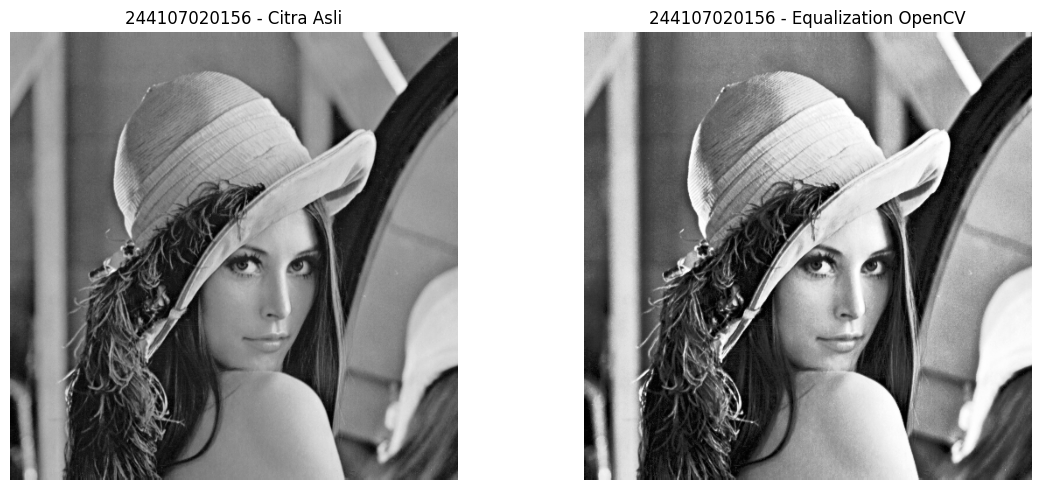

In [18]:
# E-2.2 - Histogram Equalization menggunakan OpenCV

# Equalization menggunakan OpenCV
img_equalized_cv = cv.equalizeHist(img)

# Tampilkan hasil
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title(NIM + ' - Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_equalized_cv, cmap='gray')
plt.title(NIM + ' - Equalization OpenCV')
plt.axis('off')

plt.tight_layout()
plt.show()

In [19]:
# Membandingkan hasil manual dengan OpenCV

selisih = np.abs(
    img_equalized.astype(np.int16) -
    img_equalized_cv.astype(np.int16)
)

selisih_maksimum = np.max(selisih)

print("Selisih maksimum Manual vs OpenCV:", selisih_maksimum)

Selisih maksimum Manual vs OpenCV: 1


# No 3

In [23]:
berkas = '/content/drive/MyDrive/Google Collab/Lenna.png'

bgr = cv.imread(berkas)

# cara 1: tiap kanal diekualisasi sendiri-sendiri
kanal = list(cv.split(bgr))

for i in range(3):
    kanal[i] = cv.equalizeHist(kanal[i])

he_rgb = cv.merge(kanal)

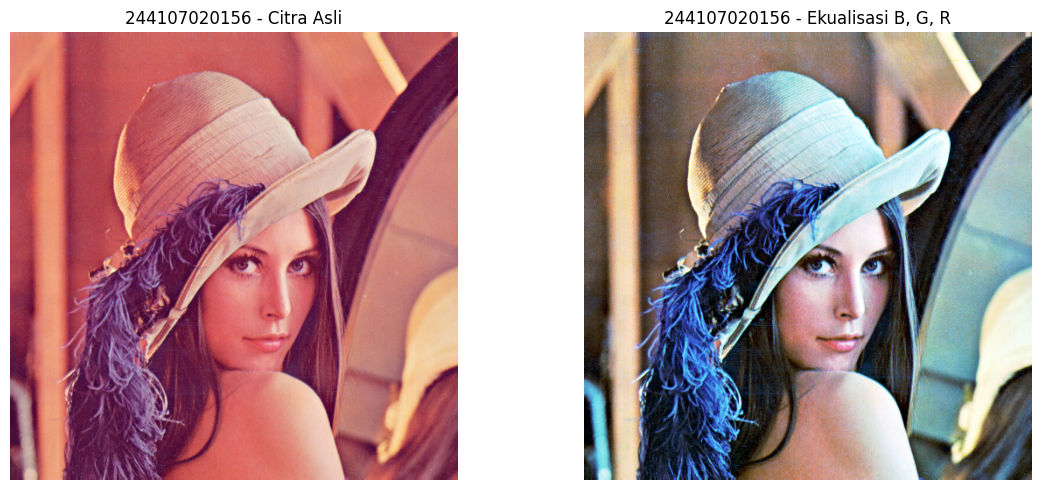

In [24]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(bgr, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Citra Asli')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(he_rgb, cv.COLOR_BGR2RGB))
plt.title(NIM + ' - Ekualisasi B, G, R')
plt.axis('off')

plt.tight_layout()
plt.show()

# No 4

In [25]:
# Cara 2: hanya kanal terang yang diekualisasi

ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
y, cr, cb = cv.split(ycrcb)

he_y = cv.cvtColor(
    cv.merge([cv.equalizeHist(y), cr, cb]),
    cv.COLOR_YCrCb2BGR
)


# Varian pada ruang warna lain

hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
h, sat, v = cv.split(hsv)

he_v = cv.cvtColor(
    cv.merge([h, sat, cv.equalizeHist(v)]),
    cv.COLOR_HSV2BGR
)


lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l, a, b = cv.split(lab)

he_l = cv.cvtColor(
    cv.merge([cv.equalizeHist(l), a, b]),
    cv.COLOR_LAB2BGR
)

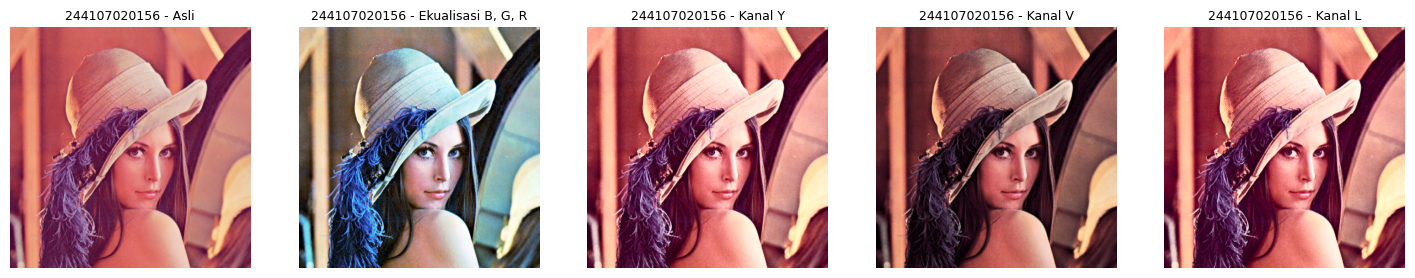

In [26]:
judul = [
    'Asli',
    'Ekualisasi B, G, R',
    'Kanal Y',
    'Kanal V',
    'Kanal L'
]

citra = [
    bgr,
    he_rgb,
    he_y,
    he_v,
    he_l
]

plt.figure(figsize=(18, 4))

for i, (c, t) in enumerate(zip(citra, judul), 1):
    plt.subplot(1, 5, i)
    plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
    plt.title(NIM + ' - ' + t, fontsize=9)
    plt.axis('off')

plt.show()

In [27]:
def geser_hue(asli, hasil):
    h1 = cv.cvtColor(
        asli,
        cv.COLOR_BGR2HSV
    )[:, :, 0].astype(np.int16)

    h2 = cv.cvtColor(
        hasil,
        cv.COLOR_BGR2HSV
    )[:, :, 0].astype(np.int16)

    d = np.abs(h1 - h2)

    # Hue OpenCV melingkar 0-179
    d = np.minimum(d, 180 - d)

    return d.mean()


print('%-22s %16s %16s' %
      ('Cara', 'geser Hue (der)', 'rerata terang'))

for t, c in zip(judul, citra):
    print(
        '%-22s %16.2f %16.1f' %
        (
            t,
            geser_hue(bgr, c) * 2,
            cv.cvtColor(
                c,
                cv.COLOR_BGR2GRAY
            ).mean()
        )
    )

Cara                    geser Hue (der)    rerata terang
Asli                               0.00            124.0
Ekualisasi B, G, R                74.86            128.3
Kanal Y                            2.02            128.0
Kanal V                            0.68             91.2
Kanal L                            2.61            121.6


# Pertanyaan

| Cara ekualisasi          | Rata-rata pergeseran Hue (derajat) | Rerata kecerahan sesudah | Catatan pengamatan visual                                         |
| ------------------------ | ---------------------------------: | -----------------------: | ----------------------------------------------------------------- |
| Citra asli               |                                  – |                **124.0** | Citra asli                                                        |
| Ekualisasi kanal B, G, R |                         **74.86°** |                **128.3** | Warna mengalami perubahan/bergeser cukup kuat                     |
| Kanal Y (YCrCb)          |                          **2.02°** |                **128.0** | Kecerahan meningkat dengan perubahan warna relatif kecil          |
| Kanal V (HSV)            |                          **0.68°** |                 **91.2** | Perubahan Hue sangat kecil, tetapi hasil menjadi lebih gelap      |
| Kanal L (LAB)            |                          **2.61°** |                **121.6** | Perubahan Hue kecil dan kecerahan relatif dekat dengan citra asli |


**1. Cara mana yang menghasilkan pergeseran Hue paling besar?**

Ekualisasi kanal B, G, dan R secara terpisah menghasilkan pergeseran Hue paling besar, yaitu 74,86°. Nilai ini jauh lebih besar dibandingkan Kanal Y sebesar 2,02°, Kanal V sebesar 0,68°, dan Kanal L sebesar 2,61°.

**2. Mengapa ekualisasi kanal terang tetap menghasilkan pergeseran Hue yang tidak persis nol?**

Ekualisasi hanya dilakukan pada kanal kecerahan, tetapi setelah citra dikembalikan ke ruang warna BGR terdapat proses pembulatan dan pemotongan nilai (clipping) ke rentang nilai piksel. Proses tersebut dapat menyebabkan perubahan kecil pada nilai kanal warna sehingga pergeseran Hue tidak benar-benar bernilai 0°. Hal ini terlihat dari hasil Kanal Y sebesar 2,02°, Kanal V sebesar 0,68°, dan Kanal L sebesar 2,61°.

**3. Di antara Kanal Y, V, dan L, mana yang paling sesuai?**

Di antara kanal Y, V, dan L, Kanal L (LAB) paling sesuai untuk citra ini. Berdasarkan hasil pengukuran, Kanal L menghasilkan pergeseran Hue sebesar 2,61° dan rerata kecerahan 121,6, yang masih dekat dengan citra asli dengan rerata kecerahan 124,0. Secara visual, hasil Kanal L juga mempertahankan warna wajah, topi, rambut, dan latar belakang relatif mirip dengan citra asli, sementara kontras gambar menjadi lebih baik. Sebaliknya, Kanal V memang memiliki pergeseran Hue paling kecil yaitu 0,68°, tetapi rerata kecerahannya turun menjadi 91,2 sehingga hasilnya terlihat jauh lebih gelap. Kanal Y memiliki kecerahan 128,0, tetapi perubahan visual pada rona merah terlihat lebih kuat.

# E2

# No 1

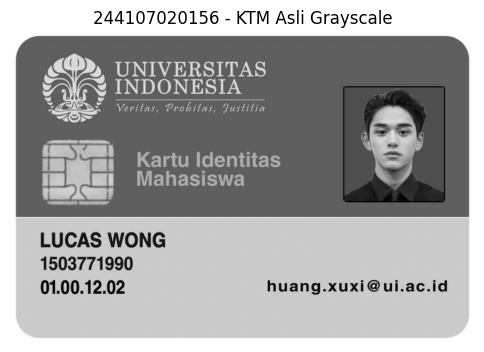

In [29]:
# Membaca KTM dalam grayscale

ktm = cv.imread(
    '/content/drive/MyDrive/Google Collab/ktm.jpg',
    cv.IMREAD_GRAYSCALE
)

plt.figure(figsize=(6, 5))
plt.imshow(ktm, cmap='gray')
plt.title(NIM + ' - KTM Asli Grayscale')
plt.axis('off')
plt.show()

In [30]:
# Histogram Equalization Manual

hist_ktm = histogram_manual(ktm)

# Probabilitas setiap intensitas
prob_ktm = hist_ktm / ktm.size

# CDF
cdf_ktm = np.cumsum(prob_ktm)

# Transformasi equalization
L = 256
transform_ktm = np.round((L - 1) * cdf_ktm).astype(np.uint8)

# Terapkan transformasi
ktm_equalized_manual = transform_ktm[ktm]

In [31]:
# Histogram Equalization menggunakan OpenCV

ktm_equalized_cv = cv.equalizeHist(ktm)

In [33]:
# Selisih maksimum hasil manual dan OpenCV

selisih_ktm = np.abs(
    ktm_equalized_manual.astype(np.int16) -
    ktm_equalized_cv.astype(np.int16)
)

print(
    'Selisih maksimum Manual vs OpenCV:',
    np.max(selisih_ktm)
)

Selisih maksimum Manual vs OpenCV: 1


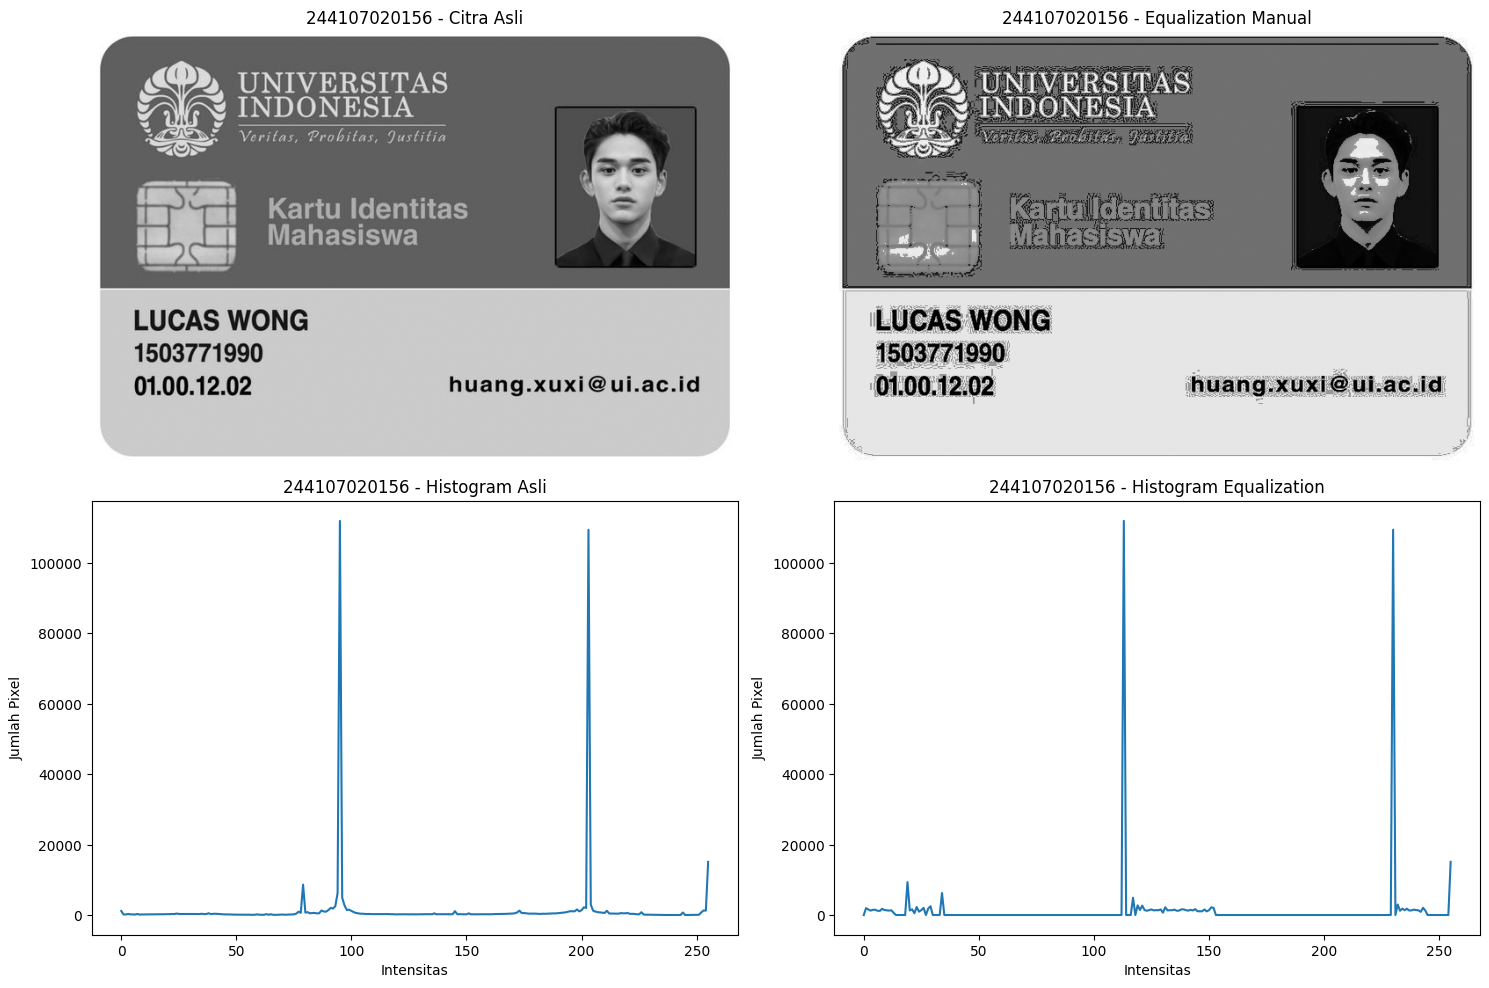

In [34]:
# Histogram sebelum dan sesudah

hist_before = histogram_manual(ktm)
hist_after = histogram_manual(ktm_equalized_manual)

plt.figure(figsize=(15, 10))

# Citra asli
plt.subplot(2, 2, 1)
plt.imshow(ktm, cmap='gray')
plt.title(NIM + ' - Citra Asli')
plt.axis('off')

# Hasil equalization manual
plt.subplot(2, 2, 2)
plt.imshow(ktm_equalized_manual, cmap='gray')
plt.title(NIM + ' - Equalization Manual')
plt.axis('off')

# Histogram asli
plt.subplot(2, 2, 3)
plt.plot(hist_before)
plt.title(NIM + ' - Histogram Asli')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

# Histogram hasil equalization
plt.subplot(2, 2, 4)
plt.plot(hist_after)
plt.title(NIM + ' - Histogram Equalization')
plt.xlabel('Intensitas')
plt.ylabel('Jumlah Pixel')

plt.tight_layout()
plt.show()

In [35]:
# Menghitung PSNR

psnr = cv.PSNR(
    ktm,
    ktm_equalized_manual
)

print('PSNR:', psnr, 'dB')

PSNR: 18.537537531167846 dB


# No 2

In [36]:
clipLimit = PARAM['clip']
tileGridSize = (PARAM['tile'], PARAM['tile'])

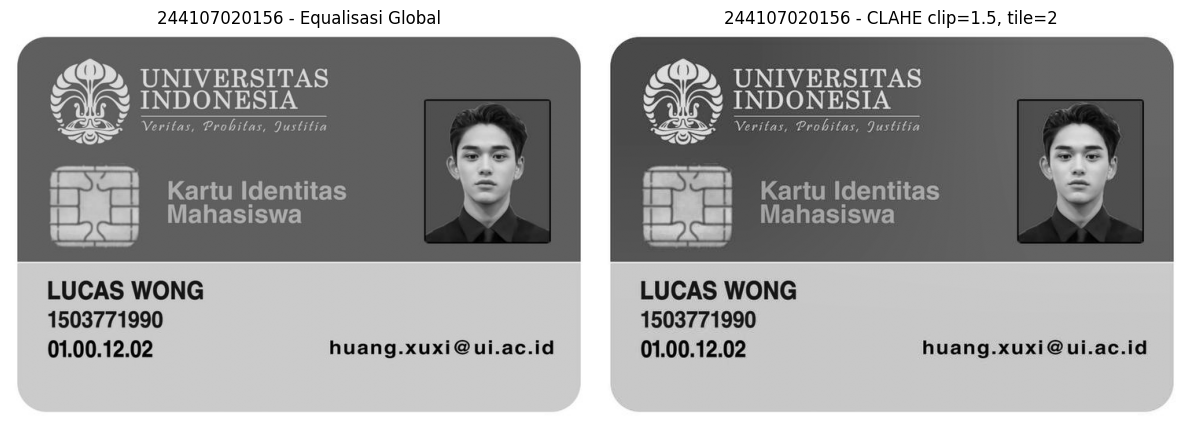

In [37]:
# E-2.2 - CLAHE

# Membaca KTM grayscale
ktm = cv.imread(
    '/content/drive/MyDrive/Google Collab/ktm.jpg',
    cv.IMREAD_GRAYSCALE
)

# Membuat CLAHE berdasarkan parameter NIM
clahe = cv.createCLAHE(
    clipLimit=PARAM['clip'],
    tileGridSize=(PARAM['tile'], PARAM['tile'])
)

# Terapkan CLAHE
ktm_clahe = clahe.apply(ktm)

# Tampilkan perbandingan
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(ktm, cmap='gray')
plt.title(NIM + ' - Equalisasi Global')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(ktm_clahe, cmap='gray')
plt.title(
    NIM + f" - CLAHE clip={PARAM['clip']}, tile={PARAM['tile']}"
)
plt.axis('off')

plt.tight_layout()
plt.show()

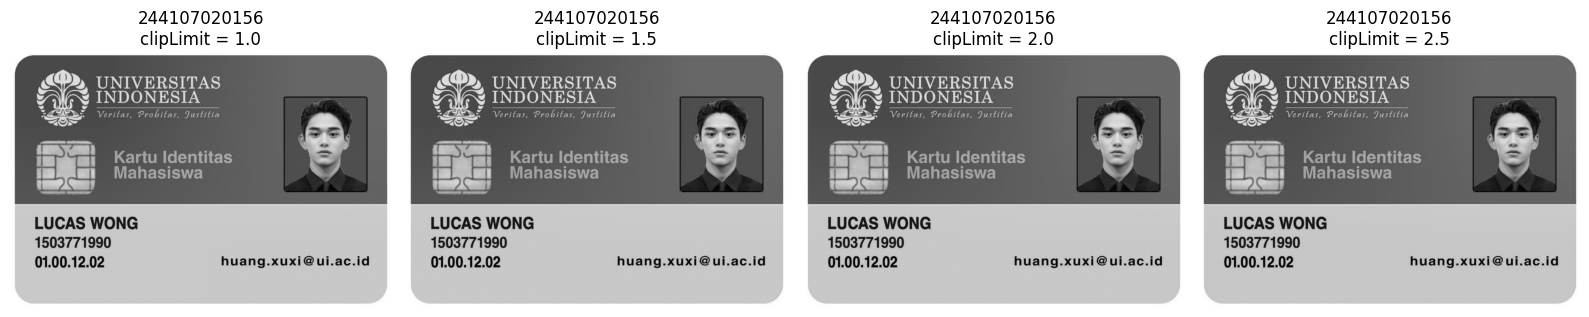

In [38]:
# Mencoba 3 nilai clipLimit di sekitar nilai parameter NIM

clip_asli = PARAM['clip']

clip_values = [
    max(0.1, clip_asli - 0.5),
    clip_asli,
    clip_asli + 0.5,
    clip_asli + 1.0
]

plt.figure(figsize=(16, 4))

for i, clip in enumerate(clip_values, 1):

    clahe = cv.createCLAHE(
        clipLimit=clip,
        tileGridSize=(PARAM['tile'], PARAM['tile'])
    )

    hasil = clahe.apply(ktm)

    plt.subplot(1, 4, i)
    plt.imshow(hasil, cmap='gray')
    plt.title(
        NIM + f'\nclipLimit = {clip}'
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

# E3

# No 1

In [39]:
def floyd_steinberg(gray, L=2):
    img = gray.astype(np.float32).copy()

    step = 255.0 / (L - 1)

    H, W = img.shape

    for y in range(H):
        for x in range(W):

            lama = img[y, x]

            baru = np.round(lama / step) * step

            img[y, x] = baru

            error = lama - baru

            if x + 1 < W:
                img[y, x + 1] += error * 7 / 16

            if x > 0 and y + 1 < H:
                img[y + 1, x - 1] += error * 3 / 16

            if y + 1 < H:
                img[y + 1, x] += error * 5 / 16

            if x + 1 < W and y + 1 < H:
                img[y + 1, x + 1] += error * 1 / 16

    return np.clip(img, 0, 255).astype(np.uint8)

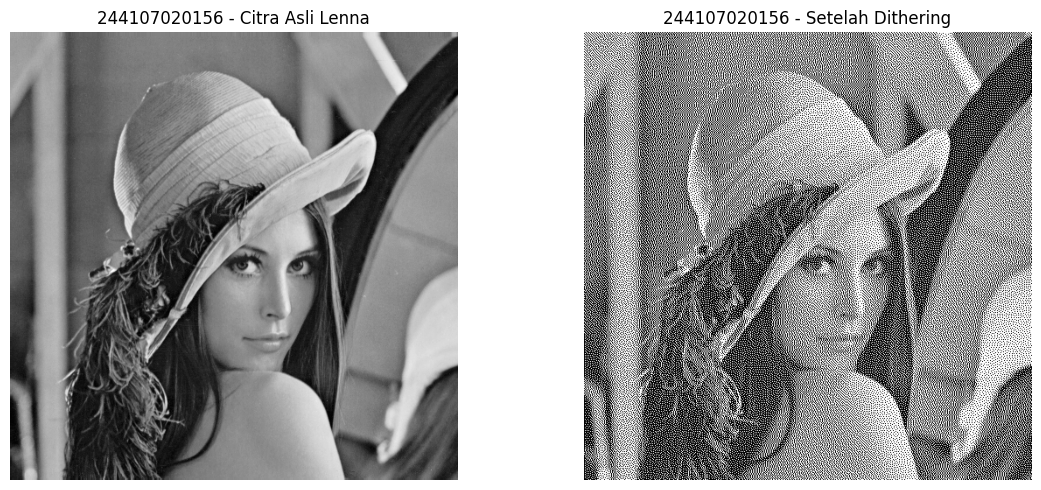

In [40]:
# Membaca Lenna sebagai grayscale
lenna = cv.imread(
    '/content/drive/MyDrive/Google Collab/Lenna.png',
    cv.IMREAD_GRAYSCALE
)

# Floyd-Steinberg 2 level
lenna_dither = floyd_steinberg(lenna, L=2)

# Tampilkan sebelum dan sesudah
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(lenna, cmap='gray')
plt.title(NIM + ' - Citra Asli Lenna')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(lenna_dither, cmap='gray')
plt.title(NIM + ' - Setelah Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()

# No 2

In [41]:
# E-3.2
# Grayscale -> Histogram Equalization -> Floyd-Steinberg

# Membaca KTM sebagai grayscale
ktm = cv.imread(
    '/content/drive/MyDrive/Google Collab/ktm.jpg',
    cv.IMREAD_GRAYSCALE
)

# Histogram Equalization manual
hist_ktm = histogram_manual(ktm)

prob_ktm = hist_ktm / ktm.size

cdf_ktm = np.cumsum(prob_ktm)

L = 256
transform_ktm = np.round(
    (L - 1) * cdf_ktm
).astype(np.uint8)

ktm_equalized = transform_ktm[ktm]

# Dithering langsung
ktm_dither_langsung = floyd_steinberg(
    ktm,
    L=PARAM['L']
)

# Dithering setelah equalization
ktm_equalized_dither = floyd_steinberg(
    ktm_equalized,
    L=PARAM['L']
)

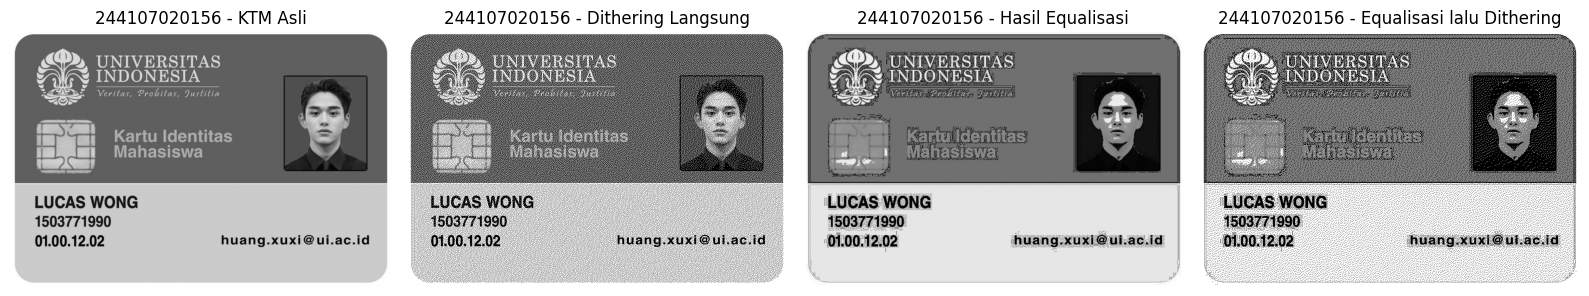

In [42]:
plt.figure(figsize=(16, 5))

# 1. Asli
plt.subplot(1, 4, 1)
plt.imshow(ktm, cmap='gray')
plt.title(NIM + ' - KTM Asli')
plt.axis('off')

# 2. Dithering langsung
plt.subplot(1, 4, 2)
plt.imshow(ktm_dither_langsung, cmap='gray')
plt.title(NIM + ' - Dithering Langsung')
plt.axis('off')

# 3. Hasil equalization
plt.subplot(1, 4, 3)
plt.imshow(ktm_equalized, cmap='gray')
plt.title(NIM + ' - Hasil Equalisasi')
plt.axis('off')

# 4. Equalisasi lalu dithering
plt.subplot(1, 4, 4)
plt.imshow(ktm_equalized_dither, cmap='gray')
plt.title(NIM + ' - Equalisasi lalu Dithering')
plt.axis('off')

plt.tight_layout()
plt.show()